<h1>Chapter 8-Forecasting Alcohol Sales</h1>

<p>We now apply an LSTM model to forecast alcohol sales. The data are obtained from the
Federal Reserve Bank of St. Louis (FRED), which provides a large collection of economic
time series.</p>
<p>For cross-sectional data, we can randomly split observations into training and testing sets.
However, this approach does not work for time series data, because the order of
observations matters.</p>
<p>Instead, we:</p>

<p>Use earlier observations for training</p>
<p>Use later observations for testing</p>
<p>In this example:</p>
<p>Training data: observations up to index 384</p>
<p>Testing data: the remaining observations, the last 24 months</p>

            Sales
Date             
1992-01-01   1414
1992-02-01   1444
1992-03-01   1496
1992-04-01   1569
1992-05-01   1707


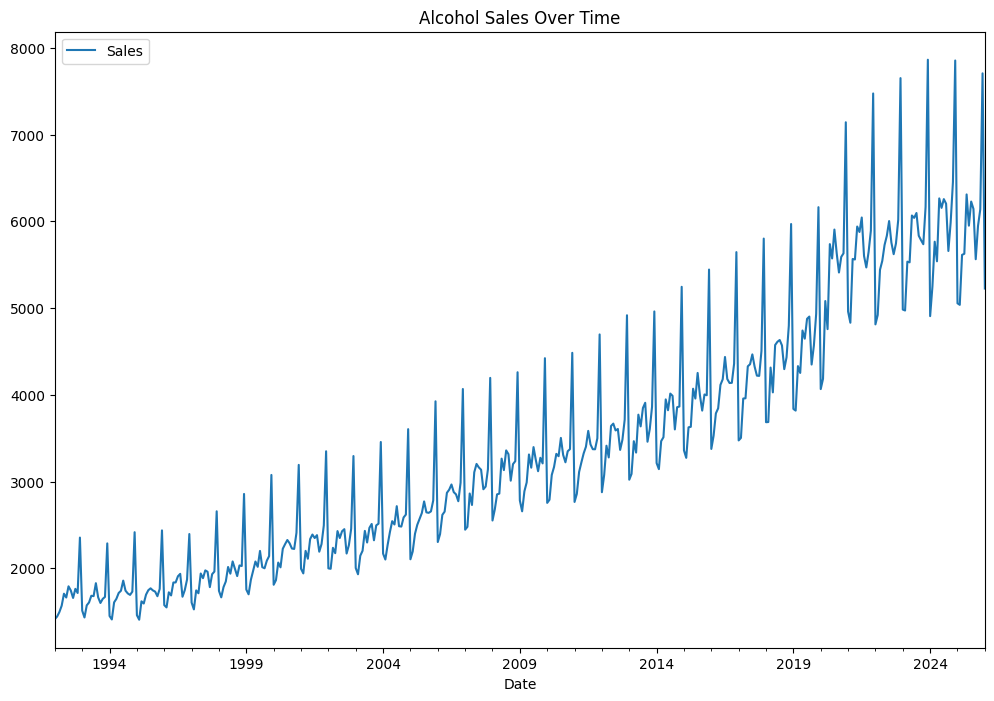

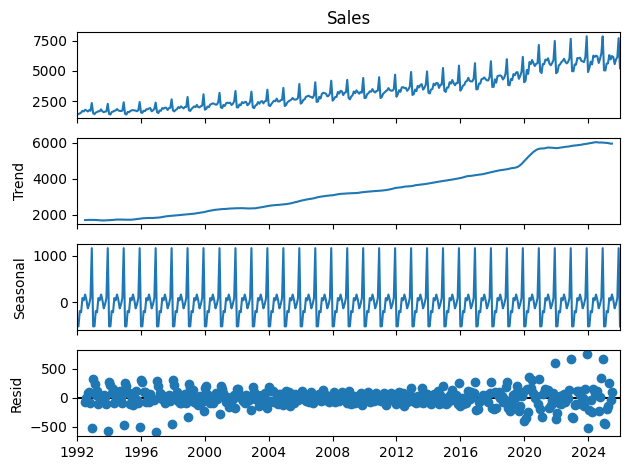

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 24, 36)              │           5,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 36)                  │          10,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              37 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,021 (62.58 KB)

 Trainable params: 16,021 (62.58 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0467 - val_loss: 2.7254e-04
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0060 - val_loss: 0.0303
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0052 - val_loss: 0.0295
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0052 - val_loss: 0.0291
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0051 - val_loss: 0.0324
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0050 - val_loss: 0.0191
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0050 - val_loss: 0.0170
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0050 - val_loss: 0.0291
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0050 - val_loss: 0.0228
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0052 - val_loss: 0.0182
Epoch 11/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0052 - val_loss: 0.0105


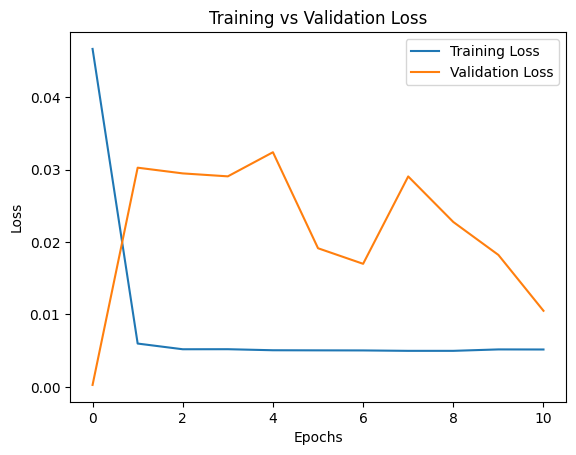

RMSE: 1315.2450082876494


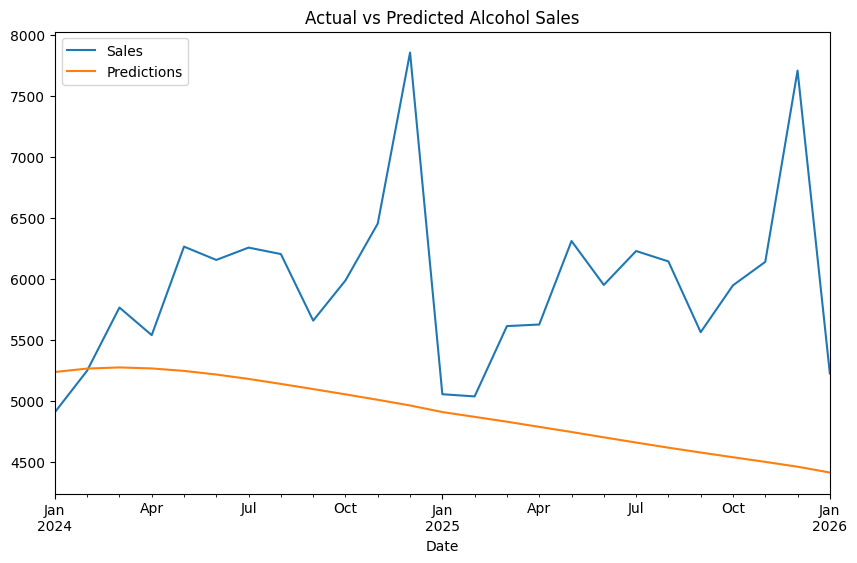

In [2]:
# ============================================================
# IMPROVED LSTM NEURAL NETWORK: ALCOHOL SALES FORECASTING
# ============================================================
# Improvements:
# 1. Uses 24 months of history (captures longer patterns)
# 2. Uses tanh activation (better for LSTM)
# 3. Adds a second LSTM layer (deeper learning)
# 4. Uses dropout (reduces overfitting)
# 5. Uses early stopping (prevents overtraining)
# 6. Evaluates model using RMSE
# ============================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from keras.layers import Input
from keras.callbacks import EarlyStopping

from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# =========================
# 2. LOAD AND PREPARE DATA
# =========================

df = pd.read_csv(
    'Chapter_08-alcohol_sales.csv',
    index_col='Date',
    parse_dates=True
)

df.index.freq = 'MS'
df.columns = ['Sales']

print(df.head())

# =========================
# 3. VISUALIZE DATA
# =========================

df.plot(figsize=(12, 8), title="Alcohol Sales Over Time")
plt.show()

# We decompose the sales into the long term trend and the seasonal variation
results = seasonal_decompose(df['Sales'])
# We plot the data to look at it
# Add a semicolon if we get two graphs
results.plot()
plt.show()

# =========================
# 4. TRAIN-TEST SPLIT
# =========================

train = df.iloc[:384].copy()
test = df.iloc[384:].copy()

# =========================
# 5. SCALE DATA
# =========================

scaler = MinMaxScaler()
scaler.fit(train)

scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

# =========================
# 6. TIME SERIES GENERATOR
# =========================

# Use 24 months instead of 12
n_input = 24
n_features = 1

train_generator = TimeseriesGenerator(
    scaled_train,
    scaled_train,
    length=n_input,
    batch_size=10
)

# Validation generator (for monitoring performance)
test_generator = TimeseriesGenerator(
    scaled_test,
    scaled_test,
    length=n_input,
    batch_size=1
)

# =========================
# 7. BUILD IMPROVED LSTM MODEL
# =========================

model = Sequential()

# Define input layer (24 months, 1 feature)
model.add(Input(shape=(n_input, n_features)))

# First LSTM layer
model.add(LSTM(
    36,
    activation='tanh',
    return_sequences=True
))

# Second LSTM layer
model.add(LSTM(36, activation='tanh'))

# Output layer
model.add(Dense(1))

# Compile model
model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

# =========================
# 8. TRAIN MODEL (WITH EARLY STOPPING)
# =========================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    epochs=100,
    validation_data=test_generator,
    callbacks=[early_stop],
    verbose=1
)

# =========================
# 9. PLOT TRAINING PERFORMANCE
# =========================

train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure()
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# =========================
# 10. MAKE FORECASTS
# =========================

test_predictions = []

first_eval_batch = scaled_train[-n_input:]
current_batch = first_eval_batch.reshape((1, n_input, n_features))

for i in range(len(test)):

    current_pred = model.predict(current_batch, verbose=0)[0]
    test_predictions.append(current_pred)

    current_batch = np.append(
        current_batch[:, 1:, :],
        [[current_pred]],
        axis=1
    )

# =========================
# 11. INVERSE TRANSFORM
# =========================

true_predictions = scaler.inverse_transform(test_predictions)

# =========================
# 12. EVALUATE MODEL
# =========================

test['Predictions'] = true_predictions

# Root Mean Squared Error (best for forecasting)
rmse = np.sqrt(mean_squared_error(test['Sales'], test['Predictions']))

print("RMSE:", rmse)

# =========================
# 13. PLOT RESULTS
# =========================

test.plot(figsize=(10, 6), title="Actual vs Predicted Alcohol Sales")
plt.show()

# =========================
# 14. SAVE / LOAD MODEL
# =========================

# model.save('Improved_LSTM_Model.h5')

# from keras.models import load_model
# new_model = load_model('Improved_LSTM_Model.h5')